In [1]:
# ==========================================
# Cell 1: Imports and Directory Setup
# ==========================================
import os
import glob
import pickle
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import Table
from tqdm import tqdm

import slsim.Sources as sources
from utils import extract_non_lens_properties, make_multiband_images_and_rgb_image

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Define and create output directories
img_dir = "../data/non-lenses/images/"
table_dir = "../data/non-lenses/"
os.makedirs(img_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)



In [2]:
# ==========================================
# Cell 2: Setup Field Galaxy Population
# ==========================================
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area_galaxy = Quantity(50, "deg2")

print("Loading SkyPy catalog for field galaxies...")
all_galaxy_catalog = Table.read(f'../catalogs/skypy_all_galaxies_{sky_area_galaxy.value}deg2.fits', format='fits')

field_galaxy_pop = sources.Galaxies(
    galaxy_list=all_galaxy_catalog, 
    kwargs_cut={"band": "i", "band_max": 26, "z_min": 0.00, "z_max": 5.0}, 
    cosmo=cosmo, 
    sky_area=sky_area_galaxy, 
    catalog_type="skypy"
)



Loading SkyPy catalog for field galaxies...


In [3]:
# ==========================================
# Cell 3: Load Non-Lens Categories (1-5)
# ==========================================
non_lens_categories = [
    "gal_gal_agn", "qso_gal", "qso_qso", "qso_star", "star_star"
]

all_non_lenses = []

print("Loading non-lens objects...")
for cat in non_lens_categories:
    files = glob.glob(f"../saved_objects/nonlenses_{cat}_*.pkl")
    for file in files:
        with open(file, "rb") as f:
            all_non_lenses.extend(pickle.load(f))
            print(f"Loaded {cat} objects from {file}")

print(f"Total non-lenses loaded: {len(all_non_lenses)}")



Loading non-lens objects...
Loaded gal_gal_agn objects from ../saved_objects/nonlenses_gal_gal_agn_10000.pkl
Loaded qso_gal objects from ../saved_objects/nonlenses_qso_gal_10000.pkl
Loaded qso_qso objects from ../saved_objects/nonlenses_qso_qso_10000.pkl
Loaded qso_star objects from ../saved_objects/nonlenses_qso_star_10000.pkl
Loaded star_star objects from ../saved_objects/nonlenses_star_star_10000.pkl
Total non-lenses loaded: 50000


In [4]:
# ==========================================
# Cell 4: Extract Properties by Category
# ==========================================
from utils import extract_non_lens_properties
from astropy.table import vstack

# Categories where central light is included
has_light = ["gal_gal_agn", "qso_gal", "cusp_mimic"] 
all_tables = []

print("Extracting properties by category...")
for cat in non_lens_categories:
    # Load only the category
    files = glob.glob(f"../saved_objects/nonlenses_{cat}_*.pkl")
    cat_objects = []
    for f_path in files:
        with open(f_path, "rb") as f:
            cat_objects.extend(pickle.load(f))
            
    # Determine if this category has a central deflector
    has_central = cat in has_light
    
    # Extract with correct flag
    cat_table = extract_non_lens_properties(
        cat_objects, 
        has_central_object=has_central,
        starting_index=len(all_tables) # Keep IDs unique
    )
    
    all_tables.append(cat_table)
    print(f"Processed {cat} (Central light: {has_central})")

# Combine all tables
table_path = os.path.join(table_dir, "table_non_lenses_combined.fits")
table_non_lenses = vstack(all_tables)
table_non_lenses.write(table_path, format="fits", overwrite=True)
print(f"✅ Saved non-lens catalog to {table_path}")

Extracting properties by category...
Processed gal_gal_agn (Central light: True)
Processed qso_gal (Central light: True)
Processed qso_qso (Central light: False)
Processed qso_star (Central light: False)
Processed star_star (Central light: False)
✅ Saved non-lens catalog to ../data/non-lenses/table_non_lenses_combined.fits


In [5]:
# ==========================================
# Cell 5: Inject Field Galaxies
# ==========================================
print("Injecting field galaxies into non-lens cutouts...")
for obj in tqdm(all_non_lenses):
    obj.add_field_galaxies(field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(100, "arcsec2")))


# 100 arcsec^2 is chosen such that Area of circle enclosing the cutout of 8"x8" is fully covered, while also adding some galaxies in the outskirts to make it more realistic
# => pi*(4*sqrt(2) arcsec)^2 ~ 100 arcsec^2



Injecting field galaxies into non-lens cutouts...


100%|██████████| 50000/50000 [00:09<00:00, 5167.54it/s]


In [ ]:
# ==========================================
# Cell 6: Render and Save FITS Images
# ==========================================
print("Rendering images (coadd_years=1) and saving to disk...")

for i, obj in tqdm(enumerate(all_non_lenses), total=len(all_non_lenses)):
    # Use the Object ID generated in the catalog table for consistency
    obj_id = table_non_lenses[i]["Object ID"]
    
    multiband_image, _ = make_multiband_images_and_rgb_image(
        lens_class=obj,
        bands=['g', 'r', 'i', 'z', 'y'],
        num_pix=41,
        coadd_years=1, 
        add_noise=True,
        rgb_bands=['i', 'r', 'g'],
        rgb_stretch=0.5,
    )

    for band in ['g', 'r', 'i', 'z', 'y']:
        fits_path = os.path.join(img_dir, f"{obj_id}_{band}.fits")
        fits.writeto(fits_path, multiband_image[band], overwrite=True)

print("Non-lens rendering complete!")

# Optional: Zipping for storage
import shutil
shutil.make_archive(os.path.join(table_dir, "non_lenses_images"), 'zip', img_dir)
print(f"✅ All images zipped to {os.path.join(table_dir, 'non_lenses_images.zip')}")

Rendering images (coadd_years=1) and saving to disk...


100%|██████████| 50000/50000 [11:46<00:00, 70.76it/s]


Non-lens rendering complete!
✅ All images zipped to ../data/non-lenses/non_lenses_images.zip


In [19]:
zip_file_size = os.path.getsize(os.path.join(table_dir, "non_lenses_images.zip")) / (1024 * 1024 * 1024)  # Size in GB
print(f"Zip file size: {zip_file_size:.2f} GB")

Zip file size: 0.62 GB


In [7]:
table_non_lenses[:5]

Object ID,RA,Dec,z_central,mag_lens_g,mag_lens_r,mag_lens_i,mag_lens_z,mag_lens_y
str12,float64,float64,float64,float64,float64,float64,float64,float64
D1_N00000000,123.71062447641528,-27.246623207967716,0.6551609940261384,28.065419420372493,26.804820496089093,25.718149849167276,25.31441991109898,25.01837787740702
D1_N00000001,130.70381403730266,-59.19743669772747,0.9474052864418853,24.814982684291362,22.75354888284325,21.666548042058654,20.739344876272117,20.34281328923161
D1_N00000002,263.0166332639924,-26.732130497390187,0.9029296341342866,22.941304001330494,22.69174794082236,22.105073585475253,21.56956209898108,21.289983582816667
D1_N00000003,72.55655666736011,-48.71928774864875,0.5485393851896125,23.752051861020274,22.53185062138544,21.63059031916878,21.241949289687387,20.981590063896828
D1_N00000004,238.62207661600644,-10.674518565115086,0.4805397306550294,27.7581446050838,26.339958078764866,25.55096583471495,25.185871984644784,24.976528100231683


## Load a saved image

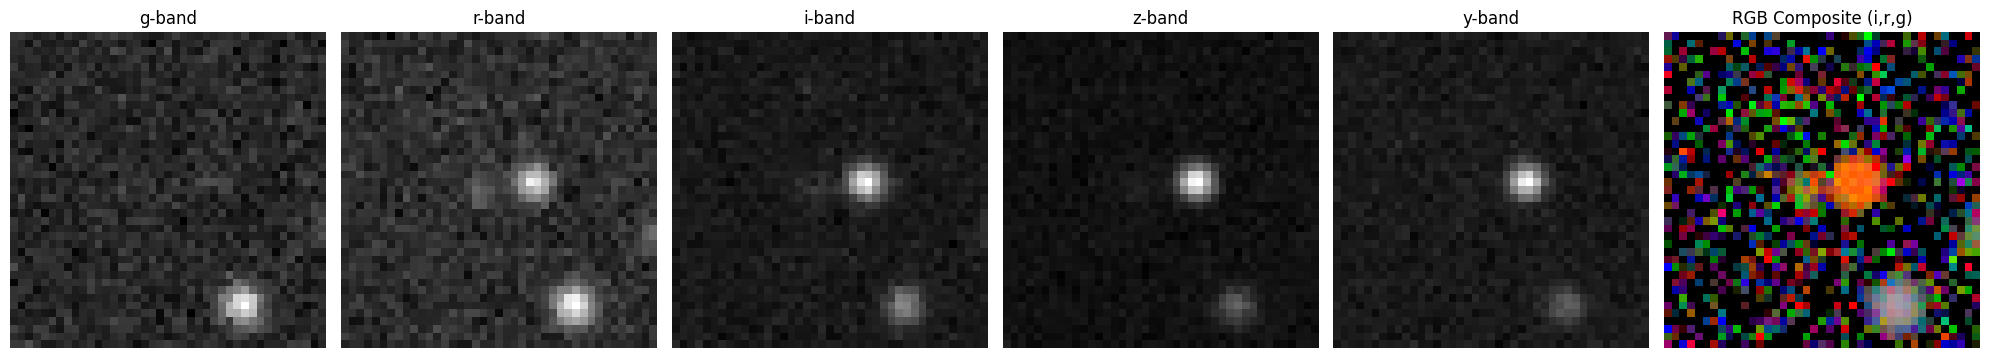

In [18]:
# load the first image in g r i z y bands to verify
test_loaded_image = {}
for band in ['g', 'r', 'i', 'z', 'y']:
    with fits.open(os.path.join(img_dir, f"{table_non_lenses[3000]['Object ID']}_{band}.fits")) as hdul:
        img_data = hdul[0].data
        test_loaded_image[band] = img_data

# figure with individual band images and then an rgb composite
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, band in enumerate(['g', 'r', 'i', 'z', 'y']):
    axes[i].imshow(test_loaded_image[band], cmap='gray', origin='lower')
    axes[i].set_title(f"{band}-band")
    axes[i].axis('off')

# Create RGB composite
from astropy.visualization import make_lupton_rgb
rgb_image = make_lupton_rgb(test_loaded_image['i'], test_loaded_image['r'], test_loaded_image['g'], stretch=.5)

axes[5].imshow(rgb_image, origin='lower')
axes[5].set_title("RGB Composite (i,r,g)")
axes[5].axis('off')
plt.tight_layout()
plt.show()